# Cover Type Classification With Deep Learning
---


# Objective
The objective of this project is to build a Deep Learning model using PyTorch to predict the forest cover type of 30x30 meter cells based on cartographic variables. This is a land management task where the goal is to identify tree species in the Roosevelt National Forest of Colorado without using actual imagery.

## Project Goals:
- Task: Multiclass Classification (7 distinct tree species).

- Model Type: Multilayer Perceptron (MLP).

- Success Metric: Achieve at least 93% accuracy on the test set.

- Approach: Use a custom nn.Module, implement efficient DataLoaders, and optimize hyperparameters using Optuna.

## Dataset Description:

The CoverType dataset is quite large, containing nearly 600,000 instances, which provides sufficient data to train a high-performance neural network.

### Input Features:

The model will process 54 attributes:

- Quantitative Data: Elevation, aspect, slope, and distances to hydrology or roadways.

- Binary Data (One-Hot): Wilderness area designations (4 columns) and soil types (40 columns).

### Target Classes:

There are 7 integer labels (1 through 7) representing different forest cover types. Technical Note: Since PyTorch's CrossEntropyLoss expects class indices to start at 0, we will transform these labels to the range 0 to 6.

# 🛠️ 1. Setup & Environment
---
Importing deep learning frameworks and checking hardware acceleration.

> **Hardware Check:** Verifying if CUDA (GPU) or MPS/TPU is available for faster training.

* **Framework:** PyTorch or TensorFlow/Keras.
* **Utilities:** Numpy, Matplotlib, OS.

In [ ]:
import sklearn
import pandas as pd
import numpy as np

In [ ]:
!pip install optuna torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 73.4 MB/s eta 0:00:00


In [ ]:
import torch
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}")

Using device: cuda


# 📂 2. Data Pipeline & Preprocessing
---
Loading data, applying transformations, and creating iterable data loaders.



### 2.1 Data Loading



In [ ]:
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

df = fetch_covtype(as_frame=True)
X = df.data
y = df.target - 1

In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42)


In [ ]:
class CoverTypeDataset(torch.utils.data.Dataset):
  def __init__(self, X, y):
    super().__init__()
    self.X = torch.tensor(X, dtype=torch.float32)
    self.y = torch.tensor(y.values, dtype=torch.long)

  def __len__(self):
    return len(self.X)
  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

### 2.2 Data preparation




In [ ]:
num_attribs = list(X.columns[:10])


num_pipeline = Pipeline([
    ('std_scaler', StandardScaler()),
])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
], remainder='passthrough')

X_train_prepared = full_pipeline.fit_transform(X_train)
X_valid_prepared = full_pipeline.transform(X_valid)
X_test_prepared = full_pipeline.transform(X_test)

train_dataset = CoverTypeDataset(X_train_prepared, y_train)
valid_dataset = CoverTypeDataset(X_valid_prepared, y_valid)
test_dataset = CoverTypeDataset(X_test_prepared, y_test)

### 2.3 Batching

In [ ]:
batch_size = 1024

train_loader = DataLoader(train_dataset, batch_size=batch_size,
shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size,
shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size,
shuffle=False)

# 🏗️ 3. Model Architecture
---
Designing the neural network topology.


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics

In [ ]:

class Dense(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.dl = nn.Sequential(
            nn.Linear(in_features, out_features),
            nn.ReLU(),
            nn.BatchNorm1d(out_features)
        )


    def forward(self, X):
        return self.dl(X)

In [ ]:
class CoverTypeModel(nn.Module):
    def __init__(self, n_neurons, n_inputs, n_classes):
        super().__init__()
        layers = [
            Dense(n_in, n_out)
            for n_in, n_out in zip([n_inputs] + n_neurons, n_neurons)
        ] + [nn.Linear(n_neurons[-1], n_classes)]
        self.mlp = nn.Sequential(*layers)

    def forward(self, X):
        return self.mlp(X)

# ⚙️ 4. Training Configuration
---
Setting up the rules for how the model will learn.


In [ ]:
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)  # update it at each iteration
    return metric.compute()  # compute the final result at the end

In [ ]:
def train(model, optimizer, criterion, metric, train_loader, valid_loader,
               n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:

            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

In [ ]:
def train_es(model, optimizer, criterion, metric, train_loader, valid_loader,
               n_epochs,patience = 5):
  history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}

  stress = 0
  best_valid_metric = 0.0
  for epoch in range(n_epochs):
    total_loss = 0
    metric.reset()
    model.train()
    for X_batch, y_batch in train_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      loss = criterion(y_pred, y_batch)
      total_loss += loss.item()
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      metric.update(y_pred, y_batch)

    mean_loss = total_loss / len(train_loader)
    train_acc = metric.compute().item()
    history["train_losses"].append(mean_loss)
    history["train_metrics"].append(train_acc)

    current_valid_metric = evaluate_tm(model, valid_loader, metric).item()
    history["valid_metrics"].append(current_valid_metric)
    print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    if current_valid_metric > best_valid_metric:

      best_valid_metric = current_valid_metric
      stress = 0
      torch.save(model.state_dict(), 'best_model.pth')
    else:

      stress += 1
      if stress == patience:
        print(f"\n Early stopping triggered ")
        model.load_state_dict(torch.load('best_model.pth'))
        break
  return history

# 🚀 5. Model Training
---
Executing the training loop over multiple epochs.



In [ ]:
#Step 1: Overfitting one Batch
model = CoverTypeModel([100,100,100], 54, 7).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
metric = torchmetrics.Accuracy(task="multiclass", num_classes=7).to(device)
X_batch, y_batch = next(iter(train_loader))
X_batch, y_batch = X_batch.to(device), y_batch.to(device)

for epoch in range(1000):

  model.train()
  y_pred = model(X_batch)
  loss = criterion(y_pred, y_batch)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if epoch % 100 == 0:
        metric.reset()
        metric.update(y_pred, y_batch)
        acc = metric.compute().item()
        print(f"Epoch {epoch} | Loss: {loss.item():.6f} | Accuracy: {acc:.4f}")

metric.reset()
metric.update(y_pred, y_batch)
print(f"Final Result -> Loss: {loss.item():.4f} | Accuracy: {metric.compute().item():.4f}")

Epoch 0 | Loss: 2.143568 | Accuracy: 0.1104
Epoch 100 | Loss: 0.113350 | Accuracy: 0.9854
Epoch 200 | Loss: 0.012832 | Accuracy: 1.0000
Epoch 300 | Loss: 0.004717 | Accuracy: 1.0000
Epoch 400 | Loss: 0.002584 | Accuracy: 1.0000
Epoch 500 | Loss: 0.001672 | Accuracy: 1.0000
Epoch 600 | Loss: 0.001183 | Accuracy: 1.0000
Epoch 700 | Loss: 0.000886 | Accuracy: 1.0000
Epoch 800 | Loss: 0.000690 | Accuracy: 1.0000
Epoch 900 | Loss: 0.000554 | Accuracy: 1.0000
Final Result -> Loss: 0.0005 | Accuracy: 1.0000


In [ ]:
#Step 2: Training the model
model = CoverTypeModel([100,100,100], 54, 7,dropout_rate=0.5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
metric = torchmetrics.Accuracy(task="multiclass", num_classes=7).to(device)

history = train(model,optimizer,criterion,metric,train_loader,valid_loader,20)

Epoch 1/20, train loss: 0.8504, train metric: 0.6609, valid metric: 0.7359
Epoch 2/20, train loss: 0.6756, train metric: 0.7200, valid metric: 0.7497
Epoch 3/20, train loss: 0.6442, train metric: 0.7310, valid metric: 0.7579
Epoch 4/20, train loss: 0.6264, train metric: 0.7364, valid metric: 0.7634
Epoch 5/20, train loss: 0.6132, train metric: 0.7412, valid metric: 0.7683
Epoch 6/20, train loss: 0.6020, train metric: 0.7443, valid metric: 0.7714
Epoch 7/20, train loss: 0.5935, train metric: 0.7478, valid metric: 0.7760
Epoch 8/20, train loss: 0.5866, train metric: 0.7520, valid metric: 0.7797
Epoch 9/20, train loss: 0.5808, train metric: 0.7531, valid metric: 0.7836
Epoch 10/20, train loss: 0.5758, train metric: 0.7558, valid metric: 0.7838
Epoch 11/20, train loss: 0.5698, train metric: 0.7577, valid metric: 0.7852
Epoch 12/20, train loss: 0.5673, train metric: 0.7588, valid metric: 0.7902


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipython-input-352639862.py", line 7, in <cell line: 0>
    history = train(model,optimizer,criterion,metric,train_loader,valid_loader,20)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-3407666354.py", line 18, in train
    metric.update(y_pred, y_batch)
  File "/usr/local/lib/python3.12/dist-packages/torchmetrics/metric.py", line 549, in wrapped_func
    update(*args, **kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torchmetrics/classification/stat_scores.py", line 344, in update
    tp, fp, tn, fn = _multiclass_stat_scores_update(
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torchmetrics/functional/classification/stat_scores.py", line 434, in _multiclass_

TypeError: object of type 'NoneType' has no len()

In [ ]:
import optuna
def objective(trial,train_loader, valid_loader,n_epochs):
  learning_rate = trial.suggest_float("learning_rate", 1e-4, 0.1, log=True)
  n_hidden = trial.suggest_int("n_hidden", 50, 200)

  model = CoverTypeModel([n_hidden, n_hidden, n_hidden], 54, 7)
  model = model.to(device)

  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

  criterion = nn.CrossEntropyLoss()

  metric = torchmetrics.Accuracy(task="multiclass", num_classes=7).to(device)

  best_validation_accuracy = 0.0
  for epoch in range(n_epochs):
    history = train(model, optimizer, criterion, metric, train_loader,
                      valid_loader, n_epochs=1)
    validation_accuracy = max(history["valid_metrics"])
    if validation_accuracy > best_validation_accuracy:
        best_validation_accuracy = validation_accuracy
    trial.report(validation_accuracy, epoch)
    if trial.should_prune():
        raise optuna.TrialPruned()
  return best_validation_accuracy

In [ ]:
#Step 3: Fine Tuning Hyperparameters
sampler = optuna.samplers.TPESampler(seed=42)

pruner = optuna.pruners.MedianPruner()

study = optuna.create_study(direction="maximize", pruner=pruner,sampler = sampler )

study.optimize(lambda trial: objective(trial, train_loader, valid_loader, n_epochs=15), n_trials=20)

print("Melhores parâmetros:", study.best_params)
print("Melhor Acurácia:", study.best_value)

[I 2026-02-13 12:32:44,703] A new study created in memory with name: no-name-3fd8486a-b0af-49a6-9b46-96946270a511


Epoch 1/1, train loss: 0.5294, train metric: 0.7955, valid metric: 0.8401
Epoch 1/1, train loss: 0.3433, train metric: 0.8578, valid metric: 0.8698
Epoch 1/1, train loss: 0.2878, train metric: 0.8820, valid metric: 0.8872
Epoch 1/1, train loss: 0.2528, train metric: 0.8970, valid metric: 0.8951
Epoch 1/1, train loss: 0.2321, train metric: 0.9061, valid metric: 0.9093
Epoch 1/1, train loss: 0.2144, train metric: 0.9135, valid metric: 0.9142
Epoch 1/1, train loss: 0.2019, train metric: 0.9182, valid metric: 0.9166
Epoch 1/1, train loss: 0.1918, train metric: 0.9226, valid metric: 0.9178
Epoch 1/1, train loss: 0.1827, train metric: 0.9263, valid metric: 0.9234
Epoch 1/1, train loss: 0.1746, train metric: 0.9295, valid metric: 0.9246
Epoch 1/1, train loss: 0.1692, train metric: 0.9318, valid metric: 0.9276
Epoch 1/1, train loss: 0.1640, train metric: 0.9341, valid metric: 0.9293
Epoch 1/1, train loss: 0.1574, train metric: 0.9369, valid metric: 0.9325
Epoch 1/1, train loss: 0.1542, train m

[I 2026-02-13 12:33:56,779] Trial 0 finished with value: 0.9325208067893982 and parameters: {'learning_rate': 0.0013292918943162175, 'n_hidden': 193}. Best is trial 0 with value: 0.9325208067893982.


Epoch 1/1, train loss: 0.1499, train metric: 0.9398, valid metric: 0.9324
Epoch 1/1, train loss: 0.5104, train metric: 0.7858, valid metric: 0.8144
Epoch 1/1, train loss: 0.3640, train metric: 0.8483, valid metric: 0.8585
Epoch 1/1, train loss: 0.3107, train metric: 0.8721, valid metric: 0.8739
Epoch 1/1, train loss: 0.2803, train metric: 0.8851, valid metric: 0.8951
Epoch 1/1, train loss: 0.2589, train metric: 0.8942, valid metric: 0.8919
Epoch 1/1, train loss: 0.2439, train metric: 0.9007, valid metric: 0.9054
Epoch 1/1, train loss: 0.2314, train metric: 0.9059, valid metric: 0.9031
Epoch 1/1, train loss: 0.2194, train metric: 0.9115, valid metric: 0.9087
Epoch 1/1, train loss: 0.2107, train metric: 0.9149, valid metric: 0.9080
Epoch 1/1, train loss: 0.2043, train metric: 0.9175, valid metric: 0.9066
Epoch 1/1, train loss: 0.1995, train metric: 0.9189, valid metric: 0.9125
Epoch 1/1, train loss: 0.1930, train metric: 0.9213, valid metric: 0.9205
Epoch 1/1, train loss: 0.1877, train m

[I 2026-02-13 12:35:38,194] Trial 1 finished with value: 0.9210215210914612 and parameters: {'learning_rate': 0.015702970884055395, 'n_hidden': 140}. Best is trial 0 with value: 0.9325208067893982.


...

Epoch 1/1, train loss: 0.5022, train metric: 0.7908, valid metric: 0.8339


[I 2026-02-13 12:44:26,846] Trial 18 pruned. 


Epoch 1/1, train loss: 0.5182, train metric: 0.7821, valid metric: 0.8200


[I 2026-02-13 12:44:31,926] Trial 19 pruned. 


Epoch 1/1, train loss: 0.5781, train metric: 0.7852, valid metric: 0.8324
Melhores parâmetros: {'learning_rate': 0.0017277890583771564, 'n_hidden': 198}
Melhor Acurácia: 0.93328458070755


In [ ]:
model = CoverTypeModel([198,198,198], 54, 7).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0017277890583771564)
criterion = nn.CrossEntropyLoss()
metric = torchmetrics.Accuracy(task="multiclass", num_classes=7).to(device)

history = train_es(model,optimizer,criterion,metric,train_loader,valid_loader,100)

Epoch 1/100, train loss: 0.5106, train metric: 0.7984, valid metric: 0.8369
Epoch 2/100, train loss: 0.3369, train metric: 0.8608, valid metric: 0.8679
Epoch 3/100, train loss: 0.2837, train metric: 0.8836, valid metric: 0.8897
Epoch 4/100, train loss: 0.2531, train metric: 0.8969, valid metric: 0.8945
Epoch 5/100, train loss: 0.2293, train metric: 0.9068, valid metric: 0.9066
Epoch 6/100, train loss: 0.2139, train metric: 0.9134, valid metric: 0.9118
Epoch 7/100, train loss: 0.2008, train metric: 0.9188, valid metric: 0.9158
Epoch 8/100, train loss: 0.1918, train metric: 0.9223, valid metric: 0.9189
Epoch 9/100, train loss: 0.1827, train metric: 0.9260, valid metric: 0.9216
Epoch 10/100, train loss: 0.1756, train metric: 0.9293, valid metric: 0.9214
Epoch 11/100, train loss: 0.1694, train metric: 0.9318, valid metric: 0.9273
Epoch 12/100, train loss: 0.1627, train metric: 0.9342, valid metric: 0.9265
Epoch 13/100, train loss: 0.1597, train metric: 0.9356, valid metric: 0.9278
Epoch 14

# 📉 6. Evaluation & Learning Curves
---
Analyzing the model's performance after training.






### 6.1 Plotting History


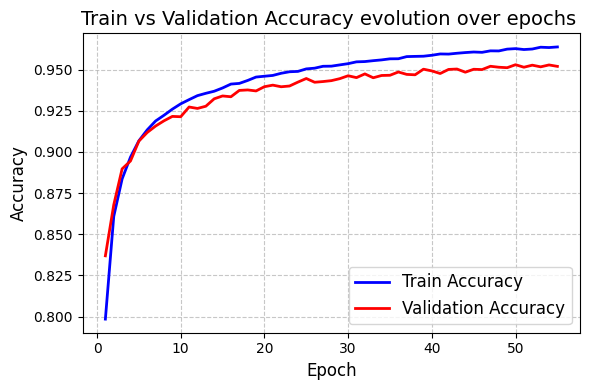

In [ ]:
import matplotlib.pyplot as plt


train_losses = history["train_losses"]
train_acc = history["train_metrics"]
valid_acc = history["valid_metrics"]
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, train_acc, 'b-', label='Train Accuracy', linewidth=2)
plt.plot(epochs, valid_acc, 'r-', label='Validation Accuracy', linewidth=2)

plt.title('Train vs Validation Accuracy evolution over epochs ', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### 6.2 Test Set Evaluation


In [ ]:
final_model = CoverTypeModel([198, 198, 198], 54, 7).to(device)


final_model.load_state_dict(torch.load('best_model.pth'))

final_model.eval()
test_metric = torchmetrics.Accuracy(task="multiclass", num_classes=7).to(device)
test_metric.reset()


with torch.no_grad():
  for X_test, y_test in test_loader:
    X_test, y_test = X_test.to(device), y_test.to(device)

    y_pred = final_model(X_test)
    test_metric.update(y_pred, y_test)

test_acc = test_metric.compute().item()

print(f"\n{'='*40}")
print(f"Accuracy on the test set: {test_acc:.2%}")
print(f"{'='*40}")


Accuracy on the test set: 95.18%
